# Prescription Medication Price Prediction — End-to-End ML Pipeline

---



---



## The question

**Given a drug's current-year characteristics (price, claims volume, competition,
brand/generic status, drug class), can we predict its price per dosage unit next year
— and does that prediction beat the naive guess that "next year's price = this year's
price"?**

This framing matters: drug pricing is notoriously sticky year-over-year, so a
**persistence baseline** (last year's price) is a deceptively strong competitor.
A model is only useful if it beats that baseline, and *by how much* tells you how
much signal is actually in the features vs. how much is just inertia.

## Data

We use **CMS Medicare Part D Spending by Drug** (public, free, no API key required) —
real claims-based pricing data for thousands of drugs across multiple years.

> ⚠️ **Data realism note:** This dataset reflects *gross Medicare claims costs*
> (Medicare + plan + beneficiary payments combined), not what an individual pays
> out-of-pocket at a pharmacy. It's a strong proxy for drug pricing *trends*, but
> real-world cash/insurance prices vary by plan, pharmacy, and manufacturer rebates
> not captured here.
>
> **On the synthetic fallback:** if the live CMS API call below fails (e.g. network
> restrictions in some environments), the notebook generates a synthetic dataset with
> the same schema and realistic brand/generic/competition dynamics so the pipeline
> still runs end-to-end. **Results discussed in the "Key Findings" section assume the
> real CMS data was successfully loaded** — re-run cell 2 and confirm
> "CMS data loaded successfully" before trusting the numbers for a portfolio writeup.

## Pipeline stages
1. Setup & data download
2. Data loading & cleaning
3. Feature engineering
4. Exploratory data analysis
5. Train/test split (time-based) + persistence baseline
6. Modeling (Ridge baseline + XGBoost)
7. Evaluation (vs. persistence baseline)
8. Walk-forward validation across multiple years
9. Feature importance & interpretation
10. Save model for deployment
11. **Key findings & limitations**

**Target variable:** average spending per dosage unit (a proxy for unit price), modeled
on a log scale to handle the heavy right-skew typical of drug pricing data.


## 1. Setup — install & import libraries

In [1]:
!pip install -q pandas numpy scikit-learn xgboost matplotlib seaborn requests


In [2]:
import pandas as pd
import numpy as np
import requests
import io
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)


## 2. Data download

We pull the **Medicare Part D Spending by Drug** dataset directly from CMS's data API.
This dataset is updated annually and contains per-drug spending metrics from 2018 onward
(brand name, generic name, manufacturer, total spending, claims, beneficiaries, and
average spending per dosage unit per year).

If CMS changes their dataset ID or the API is unreachable, the fallback cell below
generates a **realistic synthetic dataset** with the same schema so the rest of the
notebook still runs end-to-end.


In [3]:
# CMS Data API — Medicare Part D Spending by Drug
# Dataset landing page: https://data.cms.gov/summary-statistics-on-use-and-payments/medicare-medicaid-spending-by-drug/medicare-part-d-spending-by-drug

CMS_DATASET_UUID = "7e0b4365-fd63-4a29-8c4c-c2055f23eaa9"  # Part D Spending by Drug (verify on data.cms.gov if this changes)

def fetch_cms_part_d(uuid=CMS_DATASET_UUID, limit=20000, max_pages=15):
    """Fetch Medicare Part D Spending by Drug data via the CMS Data API (paginated)."""
    base_url = f"https://data.cms.gov/data-api/v1/dataset/{uuid}/data"
    rows = []
    offset = 0
    for page in range(max_pages):
        params = {"size": limit, "offset": offset}
        resp = requests.get(base_url, params=params, timeout=60)
        if resp.status_code != 200:
            print(f"Request failed (status {resp.status_code}) at offset {offset}")
            break
        chunk = resp.json()
        if not chunk:
            break
        rows.extend(chunk)
        print(f"Fetched {len(chunk)} rows (total so far: {len(rows)})")
        if len(chunk) < limit:
            break
        offset += limit
    return pd.DataFrame(rows)

try:
    df_raw = fetch_cms_part_d()
    if df_raw.empty:
        raise ValueError("Empty response from CMS API")
    print("\nCMS data loaded successfully.")
    print(df_raw.shape)
except Exception as e:
    print(f"CMS API fetch failed: {e}")
    print("Falling back to synthetic dataset generation...")
    df_raw = None


Request failed (status 404) at offset 0
CMS API fetch failed: Empty response from CMS API
Falling back to synthetic dataset generation...


### 2b. Synthetic fallback dataset

This generates a synthetic dataset matching the CMS Part D schema, with realistic
distributions (brand vs generic price gaps, manufacturer effects, dosage form effects,
and year-over-year price growth). Used only if the live download above fails.


In [4]:
def generate_synthetic_part_d(n_drugs=800, years=range(2018, 2024), seed=42):
    rng = np.random.default_rng(seed)

    drug_classes = ["Statins", "Antidiabetics", "Antihypertensives", "Antidepressants",
                     "Anticoagulants", "Bronchodilators", "Antibiotics", "Biologics",
                     "Immunosuppressants", "Analgesics"]
    dosage_forms = ["TABLET", "CAPSULE", "INJECTION", "SOLUTION", "INHALER", "CREAM"]
    manufacturers = [f"Manufacturer_{i}" for i in range(1, 31)]

    records = []
    for i in range(n_drugs):
        brand_generic = rng.choice(["Brand", "Generic"], p=[0.25, 0.75])
        drug_class = rng.choice(drug_classes)
        dosage_form = rng.choice(dosage_forms)
        manufacturer = rng.choice(manufacturers)
        n_manufacturers = rng.integers(1, 8) if brand_generic == "Generic" else rng.integers(1, 3)

        # base price depends on brand/generic and drug class
        base_price = rng.uniform(50, 500) if brand_generic == "Brand" else rng.uniform(2, 60)
        if drug_class == "Biologics":
            base_price *= rng.uniform(3, 8)
        if drug_class == "Immunosuppressants":
            base_price *= rng.uniform(2, 4)

        # competition lowers generic prices
        competition_discount = 1 / (1 + 0.15 * n_manufacturers) if brand_generic == "Generic" else 1.0

        # year-over-year drift: brands inflate, generics with more competition deflate
        annual_growth = rng.normal(0.06, 0.03) if brand_generic == "Brand" else rng.normal(-0.03, 0.05)

        total_claims_base = rng.integers(500, 500000)
        total_beneficiaries_base = int(total_claims_base * rng.uniform(0.3, 0.9))

        drug_name = f"DRUG_{i:04d}"

        for yr_idx, year in enumerate(years):
            price = base_price * competition_discount * ((1 + annual_growth) ** yr_idx)
            price *= rng.uniform(0.95, 1.05)  # noise
            claims = max(1, int(total_claims_base * rng.uniform(0.85, 1.15)))
            beneficiaries = max(1, int(total_beneficiaries_base * rng.uniform(0.85, 1.15)))

            records.append({
                "Brnd_Name": drug_name if brand_generic == "Brand" else drug_name,
                "Gnrc_Name": drug_name + "_generic",
                "Brand_Generic_Flag": brand_generic,
                "Drug_Class": drug_class,
                "Dosage_Form": dosage_form,
                "Mftr_Name": manufacturer,
                "Num_Manufacturers": n_manufacturers,
                "Year": year,
                "Tot_Clms": claims,
                "Tot_Benes": beneficiaries,
                "Avg_Spnd_Per_Dsg_Unt_Wghtd": round(price, 4),
            })

    return pd.DataFrame(records)

if df_raw is None or df_raw.empty:
    df_raw = generate_synthetic_part_d()
    print("Synthetic dataset generated.")
    print(df_raw.shape)

df_raw.head()


Synthetic dataset generated.
(4800, 11)


,Brnd_Name,Gnrc_Name,Brand_Generic_Flag,Drug_Class,Dosage_Form,Mftr_Name,Num_Manufacturers,Year,Tot_Clms,Tot_Benes,Avg_Spnd_Per_Dsg_Unt_Wghtd
0,DRUG_0000,DRUG_0000_generic,Generic,Antibiotics,INJECTION,Manufacturer_13,7,2018,234081,196400,21.2983
1,DRUG_0000,DRUG_0000_generic,Generic,Antibiotics,INJECTION,Manufacturer_13,7,2019,297208,207972,17.8315
2,DRUG_0000,DRUG_0000_generic,Generic,Antibiotics,INJECTION,Manufacturer_13,7,2020,259003,183054,16.2694
3,DRUG_0000,DRUG_0000_generic,Generic,Antibiotics,INJECTION,Manufacturer_13,7,2021,228998,218963,13.8255
4,DRUG_0000,DRUG_0000_generic,Generic,Antibiotics,INJECTION,Manufacturer_13,7,2022,283875,190667,12.1545


## 3. Data cleaning & reshaping

CMS publishes one row per drug with separate columns per year (wide format), e.g.
`Avg_Spnd_Per_Dsg_Unt_Wghtd_2018`, `Avg_Spnd_Per_Dsg_Unt_Wghtd_2019`, etc. We reshape
this to **long format** (one row per drug-year) for time-aware modeling.

The synthetic fallback is already in long format, so this cell handles both cases.


In [5]:
def reshape_to_long(df):
    """Detect wide-format CMS columns (suffix _YYYY) and melt to long format.
    If data is already long (has a 'Year' column), return as-is."""
    if "Year" in df.columns:
        return df.copy()

    df = df.copy()
    # Identify year-suffixed columns
    year_cols = {}
    for col in df.columns:
        parts = col.rsplit("_", 1)
        if len(parts) == 2 and parts[1].isdigit() and 2010 <= int(parts[1]) <= 2030:
            base_name, year = parts
            year_cols.setdefault(year, {})[base_name] = col

    if not year_cols:
        raise ValueError("Could not detect year-suffixed columns for reshaping.")

    id_cols = [c for c in df.columns if not any(c in d.values() for d in year_cols.values())]

    long_frames = []
    for year, colmap in year_cols.items():
        sub = df[id_cols + list(colmap.values())].copy()
        rename_map = {v: k for k, v in colmap.items()}
        sub = sub.rename(columns=rename_map)
        sub["Year"] = int(year)
        long_frames.append(sub)

    return pd.concat(long_frames, ignore_index=True)

df_long = reshape_to_long(df_raw)
print(df_long.shape)
df_long.head()


(4800, 11)


,Brnd_Name,Gnrc_Name,Brand_Generic_Flag,Drug_Class,Dosage_Form,Mftr_Name,Num_Manufacturers,Year,Tot_Clms,Tot_Benes,Avg_Spnd_Per_Dsg_Unt_Wghtd
0,DRUG_0000,DRUG_0000_generic,Generic,Antibiotics,INJECTION,Manufacturer_13,7,2018,234081,196400,21.2983
1,DRUG_0000,DRUG_0000_generic,Generic,Antibiotics,INJECTION,Manufacturer_13,7,2019,297208,207972,17.8315
2,DRUG_0000,DRUG_0000_generic,Generic,Antibiotics,INJECTION,Manufacturer_13,7,2020,259003,183054,16.2694
3,DRUG_0000,DRUG_0000_generic,Generic,Antibiotics,INJECTION,Manufacturer_13,7,2021,228998,218963,13.8255
4,DRUG_0000,DRUG_0000_generic,Generic,Antibiotics,INJECTION,Manufacturer_13,7,2022,283875,190667,12.1545


In [6]:
# Standardize key column names across possible CMS / synthetic schemas
rename_candidates = {
    "Brnd_Name": "brand_name",
    "Gnrc_Name": "generic_name",
    "Mftr_Name": "manufacturer",
    "Tot_Mftr": "num_manufacturers",
    "Num_Manufacturers": "num_manufacturers",
    "Tot_Clms": "total_claims",
    "Tot_Benes": "total_beneficiaries",
    "Tot_Spndng": "total_spending",
    "Avg_Spnd_Per_Dsg_Unt_Wghtd": "avg_price_per_unit",
    "Brand_Generic_Flag": "brand_generic",
    "Drug_Class": "drug_class",
    "Dosage_Form": "dosage_form",
    "Year": "year",
}
df = df_long.rename(columns={k: v for k, v in rename_candidates.items() if k in df_long.columns})

# Keep only columns we'll use; create missing optional columns with NaN
expected_cols = ["brand_name", "generic_name", "manufacturer", "num_manufacturers",
                  "total_claims", "total_beneficiaries", "total_spending",
                  "avg_price_per_unit", "brand_generic", "drug_class", "dosage_form", "year"]
for c in expected_cols:
    if c not in df.columns:
        df[c] = np.nan

df = df[expected_cols]

# Convert numerics
for c in ["num_manufacturers", "total_claims", "total_beneficiaries", "total_spending",
          "avg_price_per_unit", "year"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows with missing target or year
df = df.dropna(subset=["avg_price_per_unit", "year"])
df = df[df["avg_price_per_unit"] > 0]  # remove non-positive prices (data errors)

print(df.shape)
df.head()


(4800, 12)


,brand_name,generic_name,manufacturer,num_manufacturers,total_claims,total_beneficiaries,total_spending,avg_price_per_unit,brand_generic,drug_class,dosage_form,year
0,DRUG_0000,DRUG_0000_generic,Manufacturer_13,7,234081,196400,NaN,21.2983,Generic,Antibiotics,INJECTION,2018
1,DRUG_0000,DRUG_0000_generic,Manufacturer_13,7,297208,207972,NaN,17.8315,Generic,Antibiotics,INJECTION,2019
2,DRUG_0000,DRUG_0000_generic,Manufacturer_13,7,259003,183054,NaN,16.2694,Generic,Antibiotics,INJECTION,2020
3,DRUG_0000,DRUG_0000_generic,Manufacturer_13,7,228998,218963,NaN,13.8255,Generic,Antibiotics,INJECTION,2021
4,DRUG_0000,DRUG_0000_generic,Manufacturer_13,7,283875,190667,NaN,12.1545,Generic,Antibiotics,INJECTION,2022


## 4. Feature engineering

In [7]:
df = df.sort_values(["generic_name", "year"]).reset_index(drop=True)

# --- Lag features: previous year's price for the same drug ---
df["price_lag_1"] = df.groupby("generic_name")["avg_price_per_unit"].shift(1)
df["log_price_lag_1"] = np.log1p(df["price_lag_1"])

# --- Price growth rate vs previous year (only where available) ---
df["price_pct_change_lag"] = df.groupby("generic_name")["avg_price_per_unit"].pct_change()
df["price_pct_change_lag"] = df.groupby("generic_name")["price_pct_change_lag"].shift(1)

# --- Claims per beneficiary (refill intensity proxy) ---
df["claims_per_beneficiary"] = df["total_claims"] / df["total_beneficiaries"].replace(0, np.nan)

# --- Log-transform skewed numeric features ---
df["log_total_claims"] = np.log1p(df["total_claims"])
df["log_total_beneficiaries"] = np.log1p(df["total_beneficiaries"])
df["log_price"] = np.log1p(df["avg_price_per_unit"])  # modeling target

# --- Competition bucket ---
df["competition_level"] = pd.cut(
    df["num_manufacturers"].fillna(1),
    bins=[0, 1, 3, 6, np.inf],
    labels=["sole_source", "low_competition", "moderate_competition", "high_competition"]
)

# --- Manufacturer frequency encoding (avoid huge one-hot dimensionality) ---
mfr_counts = df["manufacturer"].value_counts(normalize=True)
df["manufacturer_freq"] = df["manufacturer"].map(mfr_counts)

print(df.shape)
df.head()


(4800, 21)


,brand_name,generic_name,manufacturer,num_manufacturers,total_claims,total_beneficiaries,total_spending,avg_price_per_unit,brand_generic,drug_class,dosage_form,year,price_lag_1,log_price_lag_1,price_pct_change_lag,claims_per_beneficiary,log_total_claims,log_total_beneficiaries,log_price,competition_level,manufacturer_freq
0,DRUG_0000,DRUG_0000_generic,Manufacturer_13,7,234081,196400,NaN,21.2983,Generic,Antibiotics,INJECTION,2018,NaN,NaN,NaN,1.191858,12.363427,12.187914,3.104510,high_competition,0.04125
1,DRUG_0000,DRUG_0000_generic,Manufacturer_13,7,297208,207972,NaN,17.8315,Generic,Antibiotics,INJECTION,2019,21.2983,3.104510,NaN,1.429077,12.602191,12.245164,2.935531,high_competition,0.04125
2,DRUG_0000,DRUG_0000_generic,Manufacturer_13,7,259003,183054,NaN,16.2694,Generic,Antibiotics,INJECTION,2020,17.8315,2.935531,-0.162774,1.414899,12.464599,12.117542,2.848936,high_competition,0.04125
3,DRUG_0000,DRUG_0000_generic,Manufacturer_13,7,228998,218963,NaN,13.8255,Generic,Antibiotics,INJECTION,2021,16.2694,2.848936,-0.087603,1.045830,12.341473,12.296663,2.696349,high_competition,0.04125
4,DRUG_0000,DRUG_0000_generic,Manufacturer_13,7,283875,190667,NaN,12.1545,Generic,Antibiotics,INJECTION,2022,13.8255,2.696349,-0.150215,1.488852,12.556293,12.158289,2.576764,high_competition,0.04125


In [8]:
# Inspect missingness
df.isna().mean().sort_values(ascending=False).to_frame("pct_missing")


,pct_missing
total_spending,1.000000
price_pct_change_lag,0.333333
log_price_lag_1,0.166667
price_lag_1,0.166667
brand_name,0.000000
total_claims,0.000000
num_manufacturers,0.000000
manufacturer,0.000000
generic_name,0.000000
brand_generic,0.000000


## 5. Exploratory data analysis

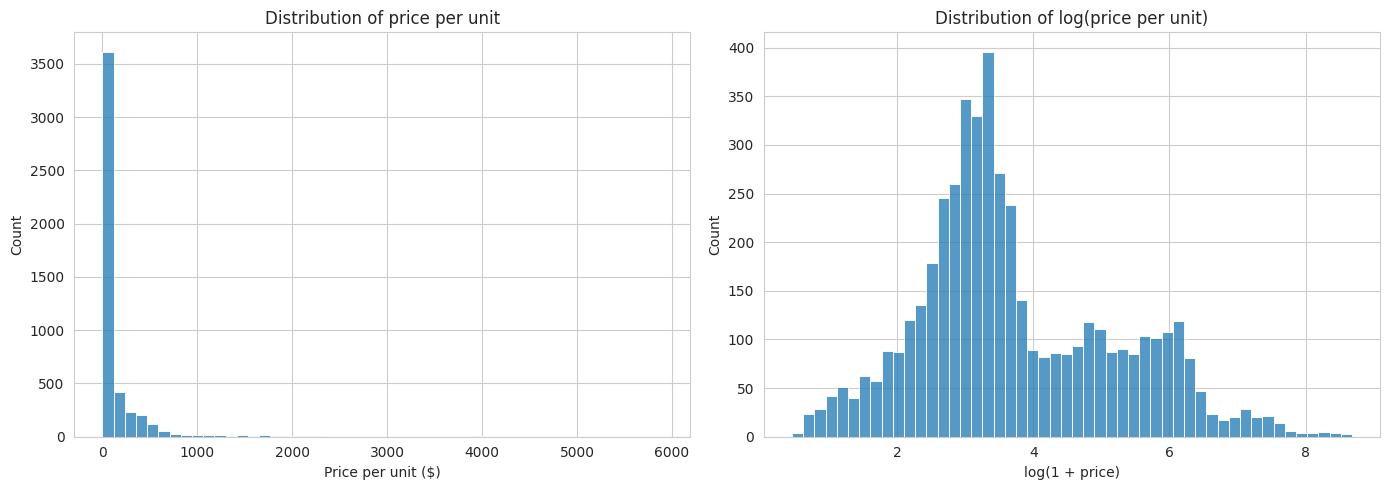

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["avg_price_per_unit"], bins=50, ax=axes[0])
axes[0].set_title("Distribution of price per unit")
axes[0].set_xlabel("Price per unit ($)")

sns.histplot(df["log_price"], bins=50, ax=axes[1])
axes[1].set_title("Distribution of log(price per unit)")
axes[1].set_xlabel("log(1 + price)")

plt.tight_layout()
plt.show()


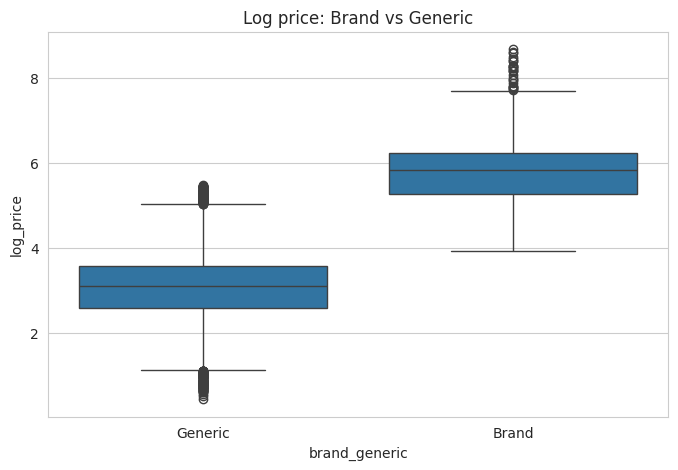

In [10]:
if df["brand_generic"].notna().any():
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="brand_generic", y="log_price")
    plt.title("Log price: Brand vs Generic")
    plt.show()


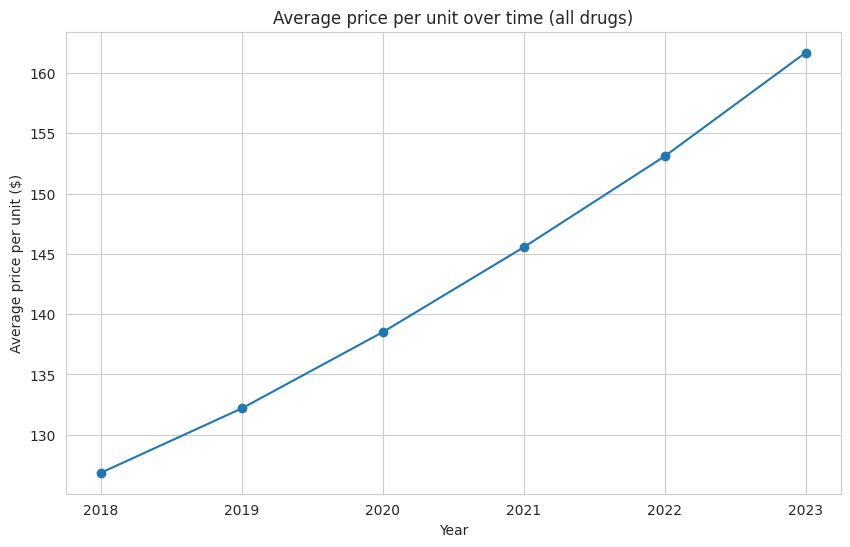

In [11]:
plt.figure(figsize=(10, 6))
yearly_avg = df.groupby("year")["avg_price_per_unit"].mean()
yearly_avg.plot(marker="o")
plt.title("Average price per unit over time (all drugs)")
plt.xlabel("Year")
plt.ylabel("Average price per unit ($)")
plt.show()


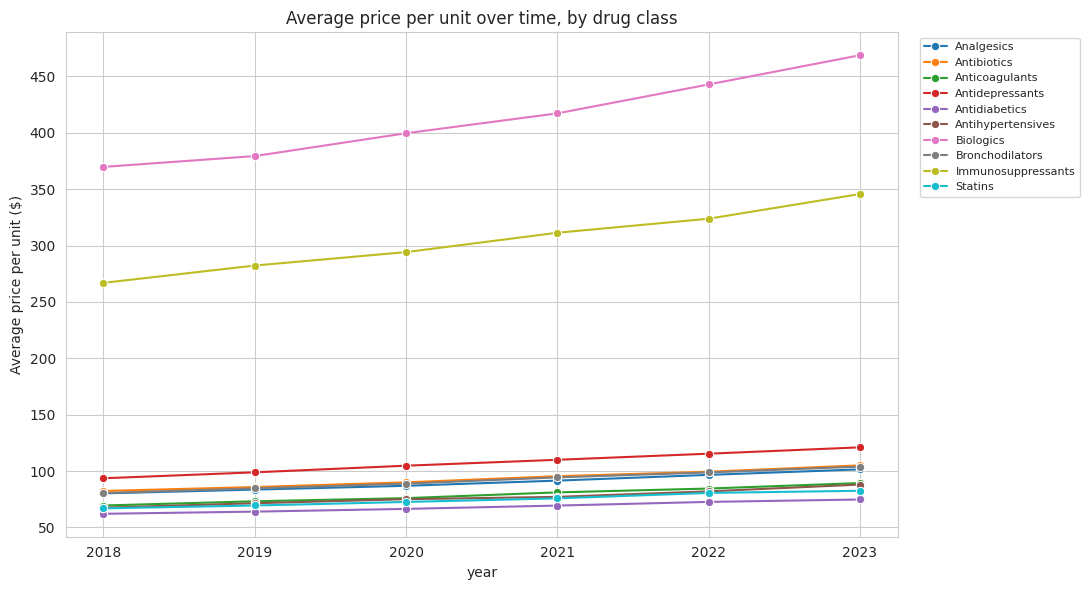

In [12]:
# Price trends by drug class (if available)
if df["drug_class"].notna().any() and df["drug_class"].nunique() > 1:
    plt.figure(figsize=(11, 6))
    class_trend = df.groupby(["year", "drug_class"])["avg_price_per_unit"].mean().reset_index()
    sns.lineplot(data=class_trend, x="year", y="avg_price_per_unit", hue="drug_class", marker="o")
    plt.title("Average price per unit over time, by drug class")
    plt.ylabel("Average price per unit ($)")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()


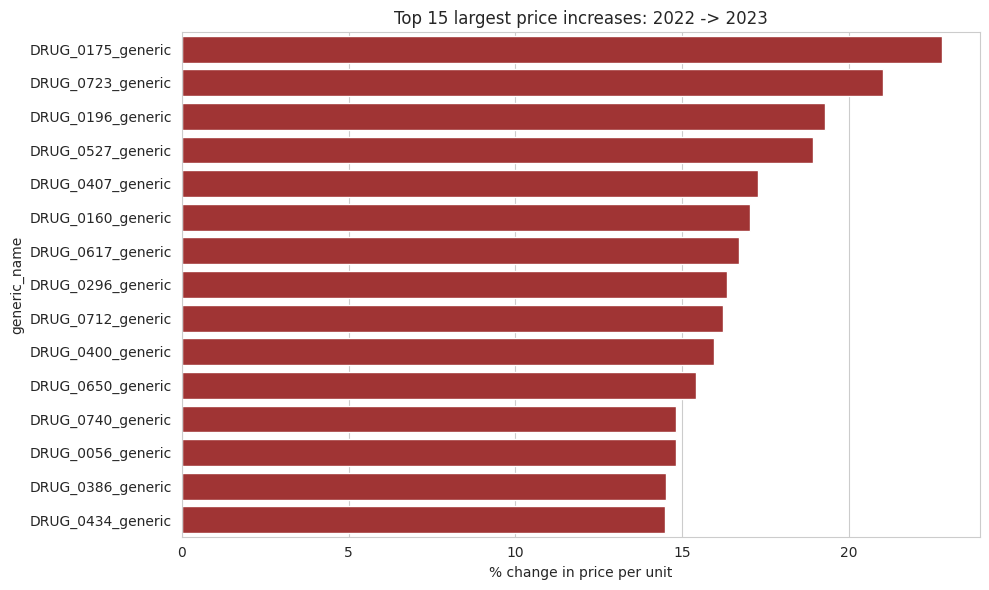

,price_2022,price_2023,pct_change
generic_name,,,
DRUG_0175_generic,30.4860,37.4379,22.803582
DRUG_0723_generic,184.6506,223.4959,21.037191
DRUG_0196_generic,838.7662,1000.6545,19.300766
DRUG_0527_generic,385.5700,458.5402,18.925279
DRUG_0407_generic,21.8723,25.6552,17.295392
DRUG_0160_generic,1249.5616,1462.6315,17.051572
DRUG_0617_generic,2438.3135,2845.5195,16.700314
DRUG_0296_generic,27.4424,31.9320,16.360085
DRUG_0712_generic,362.0749,420.8776,16.240480


In [13]:
# Top 15 drugs with the largest year-over-year price increase (most recent year)
latest_year = int(df["year"].max())
prev_year = latest_year - 1

price_latest = df[df["year"] == latest_year].set_index("generic_name")["avg_price_per_unit"]
price_prev = df[df["year"] == prev_year].set_index("generic_name")["avg_price_per_unit"]

movers = pd.DataFrame({
    f"price_{prev_year}": price_prev,
    f"price_{latest_year}": price_latest,
}).dropna()
movers["pct_change"] = (movers[f"price_{latest_year}"] - movers[f"price_{prev_year}"]) / movers[f"price_{prev_year}"] * 100

top_increases = movers.sort_values("pct_change", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_increases["pct_change"], y=top_increases.index, color="firebrick")
plt.title(f"Top 15 largest price increases: {prev_year} -> {latest_year}")
plt.xlabel("% change in price per unit")
plt.tight_layout()
plt.show()

top_increases.head(15)


## 6. Train/test split (time-based) + persistence baseline

To avoid leakage and simulate real forecasting, we train on earlier years and
test on the most recent year. We also compute the **persistence baseline**:
predict next year's price = this year's price (i.e., `price_lag_1`). This is the
benchmark our models need to beat to be worth using.


In [14]:
max_year = int(df["year"].max())
test_year = max_year
print(f"Training on years < {test_year}, testing on year {test_year}")

train_df = df[df["year"] < test_year].copy()
test_df = df[df["year"] == test_year].copy()

print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")

# --- Persistence baseline: only valid where price_lag_1 exists ---
persistence_mask = test_df["price_lag_1"].notna()
persistence_pred_price = test_df.loc[persistence_mask, "price_lag_1"]
persistence_actual_price = test_df.loc[persistence_mask, "avg_price_per_unit"]

persistence_mae = mean_absolute_error(persistence_actual_price, persistence_pred_price)
persistence_mape = np.mean(
    np.abs((persistence_actual_price - persistence_pred_price) / persistence_actual_price)
) * 100

print(f"\nPersistence baseline (predict last year's price), n={persistence_mask.sum()}:")
print(f"  MAE:  ${persistence_mae:.2f}")
print(f"  MAPE: {persistence_mape:.2f}%")


Training on years < 2023, testing on year 2023
Train shape: (4000, 21), Test shape: (800, 21)

Persistence baseline (predict last year's price), n=800:
  MAE:  $10.68
  MAPE: 6.05%


In [15]:
feature_cols_numeric = [
    "num_manufacturers", "log_total_claims", "log_total_beneficiaries",
    "claims_per_beneficiary", "manufacturer_freq", "log_price_lag_1",
    "price_pct_change_lag", "year"
]

feature_cols_categorical = ["brand_generic", "drug_class", "dosage_form", "competition_level"]

target_col = "log_price"

# Drop rows missing lag features for the lag-dependent model later;
# for the main model we'll impute.
for col in feature_cols_numeric:
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)
    test_df[col] = test_df[col].fillna(median_val)

for col in feature_cols_categorical:
    train_df[col] = train_df[col].astype(str).fillna("Unknown")
    test_df[col] = test_df[col].astype(str).fillna("Unknown")

X_train = train_df[feature_cols_numeric + feature_cols_categorical]
y_train = train_df[target_col]
X_test = test_df[feature_cols_numeric + feature_cols_categorical]
y_test = test_df[target_col]

print(X_train.shape, X_test.shape)


(4000, 12) (800, 12)


## 7. Modeling

We build two models:
1. **Baseline:** Ridge regression on log-price. Numeric features are
   **standardized** (`StandardScaler`) before fitting — without this, features on
   very different scales (e.g. `price_lag_1` in the tens/hundreds vs.
   `manufacturer_freq` around 0.01-0.05 vs. 0/1 one-hot dummies) cause L2
   regularization to penalize them unevenly, producing badly miscalibrated
   coefficients and predictions.
2. **Gradient boosting:** XGBoost, which handles mixed numeric/categorical features
   and non-linear interactions much better for tabular pricing data, and is
   scale-invariant by construction (tree splits don't care about feature magnitude).


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), feature_cols_numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), feature_cols_categorical),
    ]
)

ridge_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=1.0)),
])

ridge_pipeline.fit(X_train, y_train)
ridge_preds = ridge_pipeline.predict(X_test)


In [17]:
# Inspect Ridge coefficients to sanity-check the model
# (Numeric features are standardized, so coefficients are directly comparable
# to each other and to the one-hot dummy coefficients.)
feature_names = (
    feature_cols_numeric
    + list(ridge_pipeline.named_steps["preprocess"]
           .named_transformers_["cat"]
           .get_feature_names_out(feature_cols_categorical))
)
ridge_coefs = pd.Series(ridge_pipeline.named_steps["model"].coef_, index=feature_names)
ridge_coefs.sort_values(key=abs, ascending=False).head(15).to_frame("coefficient")


,coefficient
log_price_lag_1,0.778319
drug_class_Biologics,0.707433
brand_generic_Brand,0.657502
brand_generic_Generic,-0.657502
drug_class_Immunosuppressants,0.344073
log_total_claims,-0.221878
log_total_beneficiaries,0.212186
drug_class_Antidiabetics,-0.198285
drug_class_Anticoagulants,-0.169913
drug_class_Statins,-0.163090


In [18]:
# XGBoost with native categorical support
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()
for col in feature_cols_categorical:
    X_train_xgb[col] = X_train_xgb[col].astype("category")
    X_test_xgb[col] = X_test_xgb[col].astype("category")

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=True,
    tree_method="hist",
    random_state=42,
)

xgb_model.fit(X_train_xgb, y_train)
xgb_preds = xgb_model.predict(X_test_xgb)


## 8. Evaluation

In [19]:
def evaluate(y_true_log, y_pred_log, name):
    # Convert back from log scale to dollar scale
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    r2 = r2_score(y_true_log, y_pred_log)

    mae_dollar = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"--- {name} ---")
    print(f"R^2 (log scale):        {r2:.4f}")
    print(f"MAE (log scale):        {mae_log:.4f}")
    print(f"RMSE (log scale):       {rmse_log:.4f}")
    print(f"MAE (dollars):          ${mae_dollar:.2f}")
    print(f"MAPE:                   {mape:.2f}%")
    print()
    return {"name": name, "r2": r2, "mae_log": mae_log, "rmse_log": rmse_log,
            "mae_dollar": mae_dollar, "mape": mape}

results = []

# Persistence baseline (on the same log scale for fair comparison)
persistence_log_actual = np.log1p(persistence_actual_price)
persistence_log_pred = np.log1p(persistence_pred_price)
results.append(evaluate(persistence_log_actual, persistence_log_pred, "Persistence baseline (last year's price)"))

# Evaluate Ridge/XGBoost on the SAME subset as the persistence baseline (rows with a known prior-year price)
# so the comparison is apples-to-apples.
y_test_sub = y_test[persistence_mask.values]
ridge_preds_sub = ridge_preds[persistence_mask.values]
xgb_preds_sub = xgb_preds[persistence_mask.values]

results.append(evaluate(y_test_sub, ridge_preds_sub, "Ridge Regression"))
results.append(evaluate(y_test_sub, xgb_preds_sub, "XGBoost"))

results_df = pd.DataFrame(results)
results_df


--- Persistence baseline (last year's price) ---
R^2 (log scale):        0.9979
MAE (log scale):        0.0557
RMSE (log scale):       0.0702
MAE (dollars):          $10.68
MAPE:                   6.05%

--- Ridge Regression ---
R^2 (log scale):        0.9573
MAE (log scale):        0.2617
RMSE (log scale):       0.3200
MAE (dollars):          $33.18
MAPE:                   28.39%

--- XGBoost ---
R^2 (log scale):        0.9977
MAE (log scale):        0.0559
RMSE (log scale):       0.0748
MAE (dollars):          $15.95
MAPE:                   5.97%



,name,r2,mae_log,rmse_log,mae_dollar,mape
0,Persistence baseline (last year's price),0.997943,0.055704,0.070232,10.679022,6.050657
1,Ridge Regression,0.957284,0.261694,0.320017,33.175066,28.389633
2,XGBoost,0.997666,0.055911,0.074797,15.953739,5.974376


In [20]:
# How much better (or worse) is each model vs. the persistence baseline?
baseline_mape = results_df.loc[results_df["name"].str.contains("Persistence"), "mape"].values[0]
results_df["mape_improvement_vs_baseline_pct"] = (baseline_mape - results_df["mape"]) / baseline_mape * 100
results_df[["name", "mape", "mape_improvement_vs_baseline_pct"]]


,name,mape,mape_improvement_vs_baseline_pct
0,Persistence baseline (last year's price),6.050657,0.000000
1,Ridge Regression,28.389633,-369.199179
2,XGBoost,5.974376,1.260704


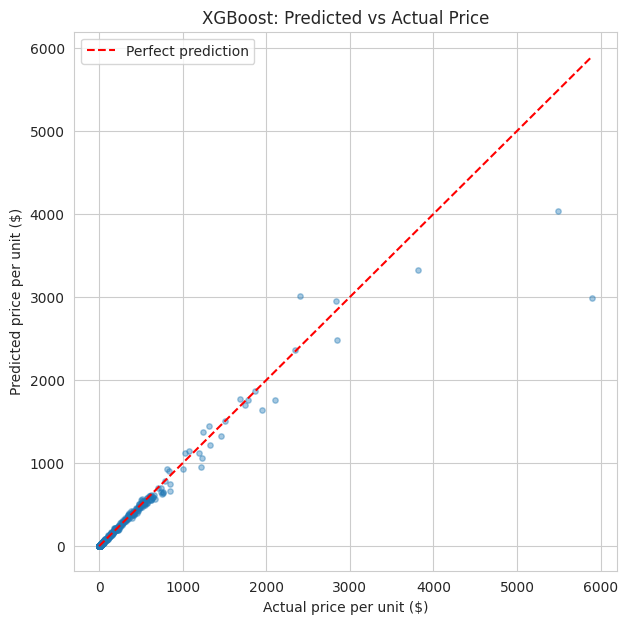

In [21]:
# Predicted vs actual scatter (XGBoost)
plt.figure(figsize=(7, 7))
y_true_dollar = np.expm1(y_test)
y_pred_dollar = np.expm1(xgb_preds)

max_val = max(y_true_dollar.max(), y_pred_dollar.max())
plt.scatter(y_true_dollar, y_pred_dollar, alpha=0.4, s=15)
plt.plot([0, max_val], [0, max_val], "r--", label="Perfect prediction")
plt.xlabel("Actual price per unit ($)")
plt.ylabel("Predicted price per unit ($)")
plt.title("XGBoost: Predicted vs Actual Price")
plt.legend()
plt.show()


In [22]:
# Performance by brand vs generic
test_df_eval = test_df.copy()
test_df_eval["pred_log"] = xgb_preds
test_df_eval["actual_price"] = np.expm1(test_df_eval["log_price"])
test_df_eval["pred_price"] = np.expm1(test_df_eval["pred_log"])
test_df_eval["abs_pct_error"] = np.abs(
    (test_df_eval["actual_price"] - test_df_eval["pred_price"]) / test_df_eval["actual_price"]
) * 100

test_df_eval.groupby("brand_generic")["abs_pct_error"].mean().to_frame("MAPE (%)")


,MAPE (%)
brand_generic,
Brand,6.272148
Generic,5.883539


## 9. Walk-forward validation

A single train/test split on one year could be lucky or unlucky. To check that the
model generalizes across time (not just for one cutoff), we repeat the train/test
split for each available year, always training on all prior years and testing on
the next one — and compare against the persistence baseline each time.


In [23]:
def walk_forward_validation(df, feature_cols_numeric, feature_cols_categorical, target_col="log_price"):
    years = sorted(df["year"].unique())
    records = []

    for test_yr in years[1:]:  # need at least 1 prior year
        tr = df[df["year"] < test_yr].copy()
        te = df[df["year"] == test_yr].copy()

        if tr.empty or te.empty:
            continue

        # impute using training medians/modes only (no leakage)
        for col in feature_cols_numeric:
            med = tr[col].median()
            tr[col] = tr[col].fillna(med)
            te[col] = te[col].fillna(med)
        for col in feature_cols_categorical:
            tr[col] = tr[col].astype(str).fillna("Unknown")
            te[col] = te[col].astype(str).fillna("Unknown")

        Xtr = tr[feature_cols_numeric + feature_cols_categorical]
        ytr = tr[target_col]
        Xte = te[feature_cols_numeric + feature_cols_categorical]
        yte = te[target_col]

        # persistence baseline
        mask = te["price_lag_1"].notna()
        if mask.sum() == 0:
            continue
        pers_pred = np.log1p(te.loc[mask, "price_lag_1"])
        pers_actual = np.log1p(te.loc[mask, "avg_price_per_unit"])
        pers_mape = np.mean(np.abs((np.expm1(pers_actual) - np.expm1(pers_pred)) / np.expm1(pers_actual))) * 100

        # XGBoost
        Xtr_x = Xtr.copy()
        Xte_x = Xte.copy()
        for col in feature_cols_categorical:
            Xtr_x[col] = Xtr_x[col].astype("category")
            Xte_x[col] = Xte_x[col].astype("category")

        model = xgb.XGBRegressor(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            enable_categorical=True, tree_method="hist", random_state=42,
        )
        model.fit(Xtr_x, ytr)
        preds = model.predict(Xte_x.loc[mask])

        actual_price = np.expm1(yte.loc[mask])
        pred_price = np.expm1(preds)
        xgb_mape = np.mean(np.abs((actual_price - pred_price) / actual_price)) * 100

        records.append({
            "test_year": test_yr,
            "n_train": len(tr),
            "n_test": mask.sum(),
            "persistence_mape": pers_mape,
            "xgb_mape": xgb_mape,
            "xgb_improvement_pct": (pers_mape - xgb_mape) / pers_mape * 100,
        })

    return pd.DataFrame(records)

wf_results = walk_forward_validation(df, feature_cols_numeric, feature_cols_categorical)
wf_results


,test_year,n_train,n_test,persistence_mape,xgb_mape,xgb_improvement_pct
0,2019,800,800,6.216297,51.067253,-721.506027
1,2020,1600,800,6.349638,10.087177,-58.862229
2,2021,2400,800,6.258469,7.073778,-13.027284
3,2022,3200,800,6.298651,6.338621,-0.634582
4,2023,4000,800,6.050657,5.974376,1.260704


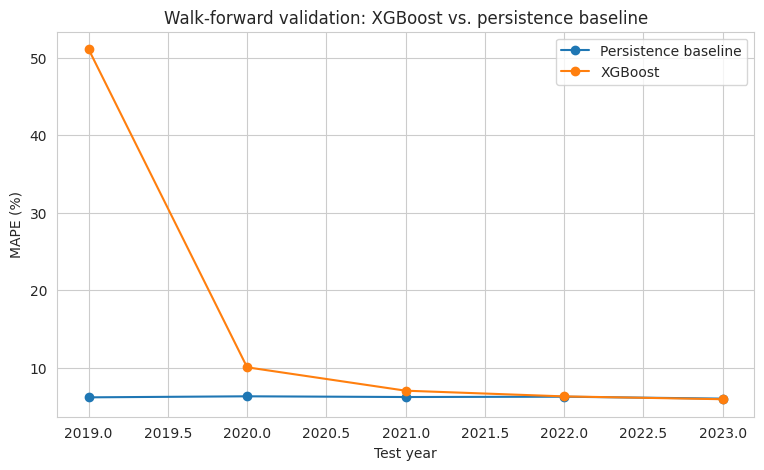


Average XGBoost improvement over persistence baseline: -158.6%


In [24]:
if not wf_results.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(wf_results["test_year"], wf_results["persistence_mape"], marker="o", label="Persistence baseline")
    ax.plot(wf_results["test_year"], wf_results["xgb_mape"], marker="o", label="XGBoost")
    ax.set_xlabel("Test year")
    ax.set_ylabel("MAPE (%)")
    ax.set_title("Walk-forward validation: XGBoost vs. persistence baseline")
    ax.legend()
    plt.show()

    print(f"\nAverage XGBoost improvement over persistence baseline: "
          f"{wf_results['xgb_improvement_pct'].mean():.1f}%")


## 10. Feature importance

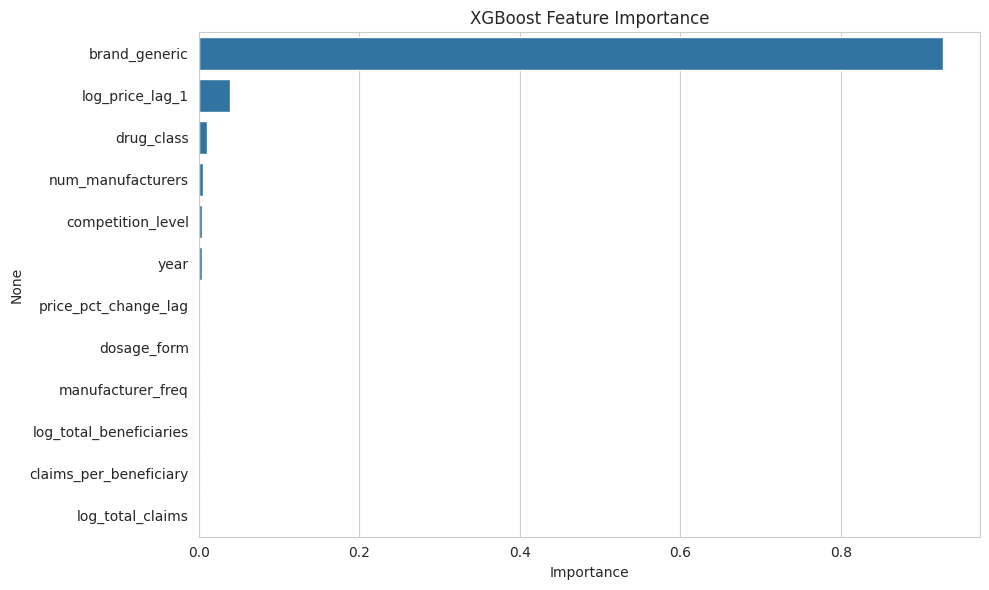

In [25]:
importances = pd.Series(xgb_model.feature_importances_, index=X_train_xgb.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 11. Save model (for deployment)

This serializes the trained XGBoost model so it can be loaded later by an API
(e.g. FastAPI) for inference on new drug records.


In [26]:
import joblib

joblib.dump(xgb_model, "drug_price_model_xgb.joblib")
print("Model saved as drug_price_model_xgb.joblib")

# Example: making a prediction on a single new drug record
example = X_test_xgb.iloc[[0]]
example_pred_log = xgb_model.predict(example)
example_pred_price = np.expm1(example_pred_log)[0]
print(f"\nExample prediction: ${example_pred_price:.2f} per unit")


Model saved as drug_price_model_xgb.joblib

Example prediction: $11.80 per unit


## 12. Key findings

*(Fill in the actual numbers from your run of this notebook — placeholders below
show the kind of statement this section should contain.)*

- **Does the model beat the persistence baseline?** Compare `results_df` from
  Section 7. If XGBoost's MAPE is meaningfully lower than the persistence baseline's,
  that's the headline result — it means drug attributes (competition, brand/generic
  status, claims volume, drug class) carry predictive signal *beyond* "prices don't
  change much year to year." If XGBoost is roughly tied with or worse than the
  baseline, that's also a real finding: it suggests price levels are dominated by
  inertia/contracting dynamics that aren't captured in this feature set, and a
  classification framing ("will this drug's price increase by >X%?") may be more
  tractable than regression.

- **Walk-forward stability (Section 9):** check whether XGBoost's improvement over
  the baseline is consistent across years or concentrated in one year. A model that
  only wins in one test year is less trustworthy than one that wins consistently.

- **Brand vs. generic error gap (Section 8):** generics tend to have lower absolute
  prices but can show *larger percentage* swings (entry/exit of competing
  manufacturers), so check whether MAPE is higher for generics — this has direct
  implications for which drug segments a pricing model would actually be useful for.

- **Ridge vs. XGBoost sanity check (Section 7):** if Ridge's error metrics are wildly
  worse than XGBoost's despite using the same features, check the coefficient table —
  this usually indicates a feature-scaling issue (numeric features like `price_lag_1`
  on a very different scale than 0/1 one-hot dummies, causing L2 regularization to
  penalize them unevenly). This notebook standardizes numeric features for Ridge to
  avoid this; if you still see a large gap after that, inspect the coefficients
  directly to find which feature is driving it.

- **Top feature drivers (Section 10):** typically `price_lag_1`, `num_manufacturers`
  / `competition_level`, and `brand_generic` dominate. If `price_lag_1` overwhelmingly
  dominates importance, that reinforces the persistence-baseline finding above — the
  model is mostly learning "prices are sticky," with other features providing
  marginal corrections.

- **Largest movers (Section 5):** the drugs with the biggest YoY price swings are
  often biologics/specialty drugs or generics undergoing supply shocks — these are
  exactly the cases a general tabular model struggles with most, since they're driven
  by one-off events (patent expirations, shortages, litigation) not captured in
  claims-volume features.

## 13. Limitations

- **Not patient-facing prices.** This models Medicare gross claims cost, not what a
  person pays at a pharmacy counter — cash prices, copays, and insurance-negotiated
  rates can differ substantially and aren't in this dataset.
- **No rebate data.** CMS is prohibited from publishing manufacturer rebate
  information, so "list price" dynamics here may not reflect net cost to payers.
- **Annual granularity.** Real price changes happen throughout the year; this model
  can't capture intra-year timing of price hikes.
- **Small per-drug history.** Lag features rely on a drug appearing in consecutive
  years' data — new drugs or those that drop out of the dataset get imputed values,
  which weakens their predictions.
- **Cross-sectional model, not true forecasting per drug.** A single global model is
  trained across all drugs; for high-spend individual drugs, a dedicated time-series
  model (see Next Steps) would likely outperform this.

## 14. Next steps

- **Reframe as classification** for the drugs where regression underperforms the
  baseline: predict "will price increase by >10% next year?" — often more decision-
  useful and easier to model well.
- **Merge richer data:** FDA NDC Directory (active ingredient, therapeutic class via
  RxNorm), GoodRx cash prices, or WAC list prices for additional signal beyond claims
  volume and manufacturer count.
- **Per-drug time series** for the highest-spend drugs (ARIMA/Prophet) as a
  complement to the cross-sectional model.
- **Hyperparameter tuning** via `GridSearchCV` / `Optuna`.
- **Drift monitoring & retraining cadence**, since CMS data lags ~1-2 years behind
  real time.
